<a href="https://colab.research.google.com/github/imagra93/ML-course-labs/blob/main/machina_learning/lab%20-%20Support%20Vector%20Machines.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Support Vector Machines (SVM)

## Introduction

**Support Vector Machines** (Vapnik & Cortes, 1995) are a powerful family of supervised learning algorithms rooted in **statistical learning theory**. Their key principle: find the decision boundary that maximises the geometric margin between classes.

SVMs have strong theoretical guarantees from **VC theory**: the generalisation error is controlled by the margin size and the complexity of the hypothesis class, independently of the input dimensionality. This makes them especially powerful in high-dimensional spaces.

### Learning Objectives
1. Understand the hard-margin and soft-margin SVM formulations
2. Derive the dual problem and understand support vectors
3. Understand the kernel trick and why it enables non-linear boundaries
4. Apply SVMs in practice with scikit-learn and tune hyperparameters

## Notation

| Symbol | Meaning |
|--------|---------|
| $m$ | Number of training samples |
| $n$ | Number of features |
| $\mathbf{x}^{(i)} \in \mathbb{R}^n$ | $i$-th training example |
| $y^{(i)} \in \{-1, +1\}$ | Class label (SVM convention: $\pm 1$, not 0/1) |
| $\mathbf{w} \in \mathbb{R}^n$ | Normal vector to the decision hyperplane |
| $b \in \mathbb{R}$ | Bias (offset) of the hyperplane |
| $\xi_i \geq 0$ | Slack variable for soft-margin SVM |
| $C > 0$ | Regularisation parameter (controls margin softness) |
| $K(\mathbf{x}, \mathbf{z})$ | Kernel function |
| $\alpha_i \geq 0$ | Lagrange multipliers (dual variables) |

In [22]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
import seaborn as sns

plt.style.use('seaborn-v0_8-whitegrid')

## Motivating Support Vector Machines

At this point, we consider the simple case of a classification task in which the two classes of points are well separated.

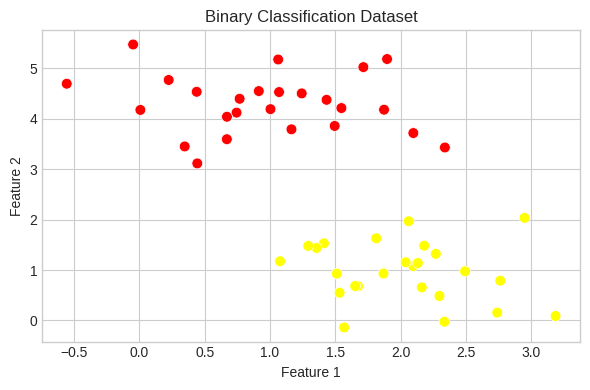

In [23]:
from sklearn.datasets import make_blobs

X, y = make_blobs(n_samples=50, centers=2, random_state=0, cluster_std=0.60)

plt.figure(figsize=(6, 4))
plt.scatter(X[:, 0], X[:, 1], c=y, s=60, cmap='autumn', edgecolors='white', linewidths=0.5)
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.title('Binary Classification Dataset')
plt.tight_layout()
plt.show()

As we saw in class, we want to find an hyperplane that tries to separate these two sets of data, and thereby create a model for classification. In this case, with just two variables, we could find that line by hand.

However, there are infinite solutions to this problem. For example:


## Mathematical Formulation

### Hard-Margin SVM (Linearly Separable Case)

The decision hyperplane is $\{\mathbf{x}: \mathbf{w}^\top\mathbf{x} + b = 0\}$. The **signed geometric distance** from point $\mathbf{x}^{(i)}$ to this hyperplane is:

$$d^{(i)} = \frac{y^{(i)}(\mathbf{w}^\top\mathbf{x}^{(i)} + b)}{\|\mathbf{w}\|}$$

The **margin** is the minimum distance across all training points: $\gamma = \min_i d^{(i)}$.

By normalising so that the closest points satisfy $y^{(i)}(\mathbf{w}^\top\mathbf{x}^{(i)} + b) = 1$, the margin becomes $\frac{2}{\|\mathbf{w}\|}$. Maximising the margin is equivalent to:

$$\boxed{\min_{\mathbf{w}, b} \frac{1}{2}\|\mathbf{w}\|^2 \quad \text{subject to} \quad y^{(i)}(\mathbf{w}^\top\mathbf{x}^{(i)} + b) \geq 1, \quad \forall i}$$

This is a **convex quadratic program (QP)** with linear constraints.

### Dual Problem

Using Lagrange multipliers $\alpha_i \geq 0$, the Lagrangian is:
$$\mathcal{L}(\mathbf{w}, b, \boldsymbol{\alpha}) = \frac{1}{2}\|\mathbf{w}\|^2 - \sum_{i=1}^m \alpha_i \left[y^{(i)}(\mathbf{w}^\top\mathbf{x}^{(i)} + b) - 1\right]$$

Setting $\nabla_{\mathbf{w}}\mathcal{L} = 0$ gives $\mathbf{w} = \sum_i \alpha_i y^{(i)} \mathbf{x}^{(i)}$. The **dual problem** is:

$$\max_{\boldsymbol{\alpha}} \sum_{i=1}^m \alpha_i - \frac{1}{2}\sum_{i,j=1}^m \alpha_i \alpha_j y^{(i)} y^{(j)} \langle\mathbf{x}^{(i)}, \mathbf{x}^{(j)}\rangle \quad \text{s.t.} \quad \alpha_i \geq 0,\; \sum_i \alpha_i y^{(i)} = 0$$

**Key observations:**
- The dual only depends on **inner products** $\langle\mathbf{x}^{(i)}, \mathbf{x}^{(j)}\rangle$ → this is where the kernel trick enters
- **Support vectors**: the points with $\alpha_i > 0$ (by KKT complementary slackness: $\alpha_i[y^{(i)}(\mathbf{w}^\top\mathbf{x}^{(i)}+b)-1]=0$)
- The decision function: $f(\mathbf{x}) = \text{sign}\left(\sum_{i \in \text{SV}} \alpha_i y^{(i)} \langle\mathbf{x}^{(i)}, \mathbf{x}\rangle + b\right)$

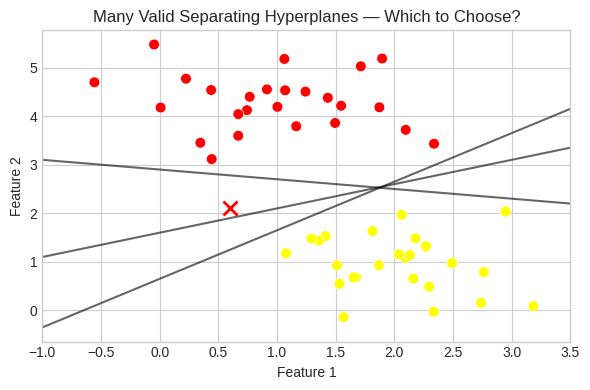

In [24]:
xfit = np.linspace(-1, 3.5)

plt.figure(figsize=(6, 4))
plt.scatter(X[:, 0], X[:, 1], c=y, s=60, cmap='autumn', edgecolors='white', linewidths=0.5)
plt.plot([0.6], [2.1], 'x', color='red', markeredgewidth=2, markersize=10)
for slope, intercept in [(1, 0.65), (0.5, 1.6), (-0.2, 2.9)]:
    plt.plot(xfit, slope * xfit + intercept, '-k', alpha=0.6)
plt.xlim(-1, 3.5)
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.title('Many Valid Separating Hyperplanes — Which to Choose?')
plt.tight_layout()
plt.show()

Depending on which you choose, a new data point (e.g., the one marked by the "x" in this plot) will be assigned a different label!


As we saw in class, we need to find the better line (hyperplane) according to some metric.

## Support Vector Machines: Maximizing the *Margin*

We look forward the *margin* to each closest point around.

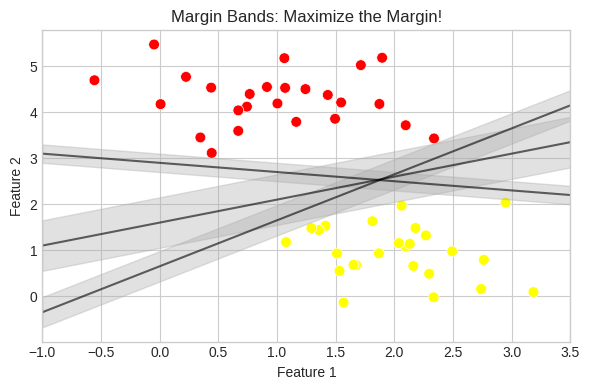

In [25]:
xfit = np.linspace(-1, 3.5)

plt.figure(figsize=(6, 4))
plt.scatter(X[:, 0], X[:, 1], c=y, s=60, cmap='autumn', edgecolors='white', linewidths=0.5)
for slope, intercept, margin in [(1, 0.65, 0.33), (0.5, 1.6, 0.55), (-0.2, 2.9, 0.2)]:
    yfit = slope * xfit + intercept
    plt.plot(xfit, yfit, '-k', alpha=0.6)
    plt.fill_between(xfit, yfit - margin, yfit + margin,
                     edgecolor='none', color='#AAAAAA', alpha=0.35)
plt.xlim(-1, 3.5)
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.title('Margin Bands: Maximize the Margin!')
plt.tight_layout()
plt.show()

In SVM, the line that maximizes this margin is the one we will choose as the optimal model, i.e. the *maximum margin* estimator. Clearly, one of the lines is better than the others in this case.

### Fitting an SVM with scikit-learn

We use `SVC(kernel='linear', C=1e10)` — a very large $C$ enforces an almost hard margin. The `fit` method solves the dual QP using the **Sequential Minimal Optimisation (SMO)** algorithm (Platt, 1998), which is far more efficient than standard QP solvers for large datasets.

In [26]:
from sklearn.svm import SVC  # "Support vector classifier"
model = SVC(kernel='linear', C=1e10)
model.fit(X, y)

SVC(C=10000000000.0, kernel='linear')

To better visualize what's happening here, let's create a quick convenience function that will plot SVM decision boundaries for us:

In [27]:
def plot_svc_decision_function(model, ax=None, plot_support=True):
    """Plot the decision function for a 2D SVC"""
    if ax is None:
        ax = plt.gca()
    xlim = ax.get_xlim()
    ylim = ax.get_ylim()

    # create grid to evaluate model
    x = np.linspace(xlim[0], xlim[1], 30)
    y = np.linspace(ylim[0], ylim[1], 30)
    Y, X = np.meshgrid(y, x)
    xy = np.vstack([X.ravel(), Y.ravel()]).T
    P = model.decision_function(xy).reshape(X.shape)

    # plot decision boundary and margins
    ax.contour(X, Y, P, colors='k',
               levels=[-1, 0, 1], alpha=0.5,
               linestyles=['--', '-', '--'])

    # plot support vectors
    if plot_support:
        ax.scatter(model.support_vectors_[:, 0],
                   model.support_vectors_[:, 1],
                   s=300, linewidth=1, facecolors='none');
    ax.set_xlim(xlim)
    ax.set_ylim(ylim)

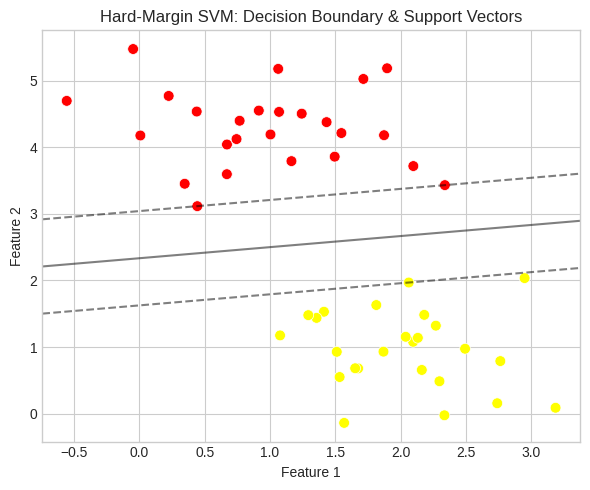

In [28]:
plt.figure(figsize=(6, 5))
plt.scatter(X[:, 0], X[:, 1], c=y, s=60, cmap='autumn',
            edgecolors='white', linewidths=0.5)
plot_svc_decision_function(model)
plt.title('Hard-Margin SVM: Decision Boundary & Support Vectors')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.tight_layout()
plt.show()

The result is the dividing hyperplane (line in our 2 dimensions) that maximizes the margin between the two sets of points.
Notice that a few of the training points just touch the margin: they are *support vectors*, and give the algorithm its name.
Let's see who this points are:

In [29]:
model.support_vectors_

array([[0.44359863, 3.11530945],
       [2.33812285, 3.43116792],
       [2.06156753, 1.96918596]])

**Key property of SVMs: only support vectors matter.**

Once the model is trained, $\mathbf{w} = \sum_{i \in \text{SV}} \alpha_i y^{(i)} \mathbf{x}^{(i)}$. Points far from the boundary (non-support vectors) have $\alpha_i = 0$ and do not contribute to the decision function.

This makes the SVM **robust to outliers far from the margin** and gives it a form of **sparsity**: only the most "difficult" points (near the boundary) determine the classifier. Contrast this with logistic regression, where all points contribute to the parameter update.

Let us verify empirically that adding more data far from the margin does not change the boundary:

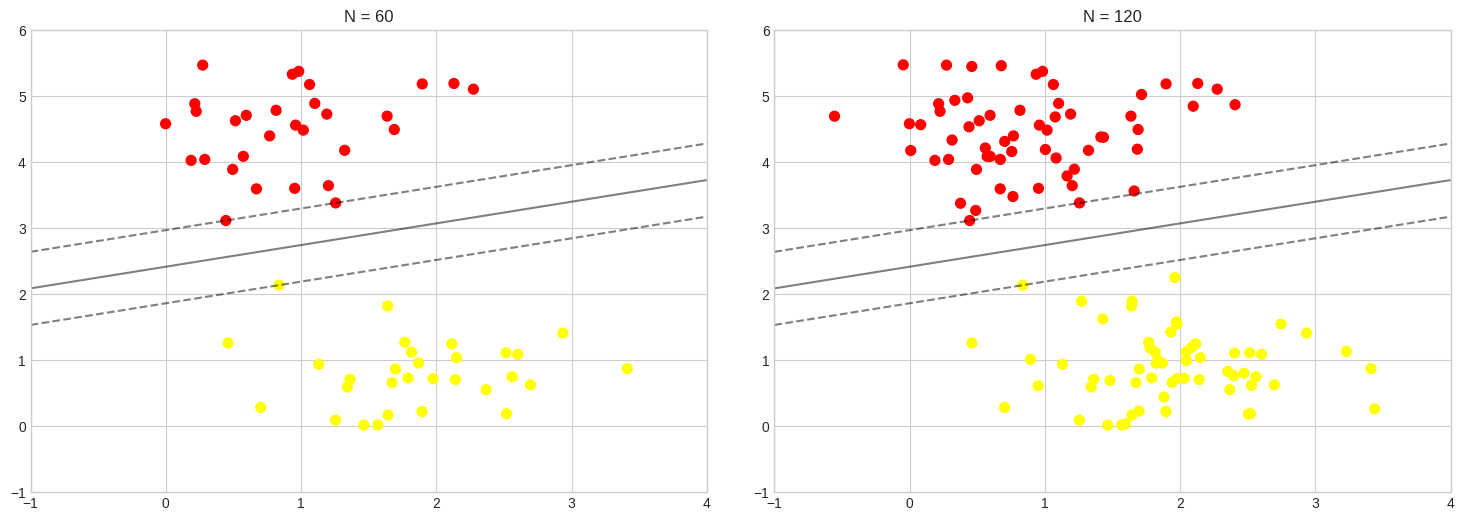

In [30]:
def plot_svm(N=10, ax=None):
    X, y = make_blobs(n_samples=200, centers=2,
                      random_state=0, cluster_std=0.60)
    X = X[:N]
    y = y[:N]
    model = SVC(kernel='linear', C=1e10)
    model.fit(X, y)

    ax = ax or plt.gca()
    ax.scatter(X[:, 0], X[:, 1], c=y, s=50, cmap='autumn')
    ax.set_xlim(-1, 4)
    ax.set_ylim(-1, 6)
    plot_svc_decision_function(model, ax)

fig, ax = plt.subplots(1, 2, figsize=(16, 6))
fig.subplots_adjust(left=0.0625, right=0.95, wspace=0.1)
for axi, N in zip(ax, [60, 120]):
    plot_svm(N, axi)
    axi.set_title(f'N = {N}')

In the left figure, we see the model and the support vectors for 60 training points.
In the right panel, we have doubled the number of training points, but the model has not changed: the three support vectors from the left panel are still the support vectors from the right panel.
This insensitivity to the exact behavior of distant points is one of the strengths of the SVM model.

### Beyond Linear Boundaries: The Kernel Trick

The dual SVM only depends on inner products $\langle\mathbf{x}^{(i)}, \mathbf{x}^{(j)}\rangle$. We can **implicitly map** inputs to a high-dimensional feature space $\phi(\mathbf{x})$ by replacing every inner product with a **kernel function**:

$$K(\mathbf{x}, \mathbf{z}) = \langle\phi(\mathbf{x}), \phi(\mathbf{z})\rangle$$

We never compute $\phi$ explicitly — only evaluations of $K$. This is the **kernel trick**.

**Common kernels:**

| Kernel | Formula | Feature Space |
|--------|---------|--------------|
| Linear | $\mathbf{x}^\top\mathbf{z}$ | Original $\mathbb{R}^n$ |
| Polynomial | $(\gamma\mathbf{x}^\top\mathbf{z} + r)^d$ | Degree-$d$ polynomial features |
| RBF/Gaussian | $\exp\!\left(-\gamma\|\mathbf{x}-\mathbf{z}\|^2\right)$ | **Infinite-dimensional** (Taylor expansion of $e^x$) |
| Sigmoid | $\tanh(\gamma\mathbf{x}^\top\mathbf{z} + r)$ | Neural-network-like |

**Mercer's theorem:** $K$ is a valid kernel (i.e., corresponds to an inner product in some Hilbert space) if and only if the Gram matrix $\mathbf{K}_{ij} = K(\mathbf{x}^{(i)}, \mathbf{x}^{(j)})$ is **positive semi-definite** for any set of inputs.

**RBF and infinite dimensions:** Using the Taylor expansion $e^x = \sum_{k=0}^\infty \frac{x^k}{k!}$:
$$K_{\text{RBF}}(\mathbf{x}, \mathbf{z}) = e^{-\gamma\|\mathbf{x}-\mathbf{z}\|^2} = e^{-\gamma\|\mathbf{x}\|^2} \cdot e^{2\gamma\mathbf{x}^\top\mathbf{z}} \cdot e^{-\gamma\|\mathbf{z}\|^2}$$
This corresponds to a feature map with infinitely many dimensions, which is why RBF SVMs can separate very complex patterns.

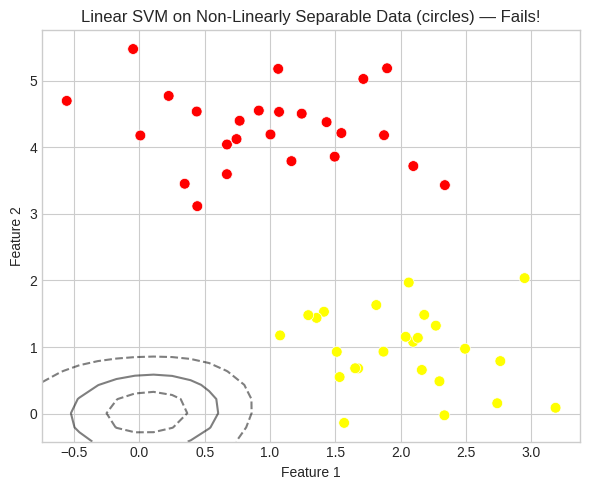

In [31]:
plt.figure(figsize=(6, 5))
plt.scatter(X[:, 0], X[:, 1], c=y, s=60, cmap='autumn',
            edgecolors='white', linewidths=0.5)
plot_svc_decision_function(clf, plot_support=False)
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.title('Linear SVM on Non-Linearly Separable Data (circles) — Fails!')
plt.tight_layout()
plt.show()

Clearly, no hyperplane (line) will *ever* be able to separate this data.
However, think about how we might project the data into a higher dimension such that a linear separator *would* be sufficient.

For example, one simple projection we could use would be to compute a *radial basis function* centered on the middle point, i.e. (0,0):

In [32]:
r = np.exp(-((X - np.zeros((1,2))) ** 2).sum(axis = 1))

We can visualize this extra data dimension using a three-dimensional plot.

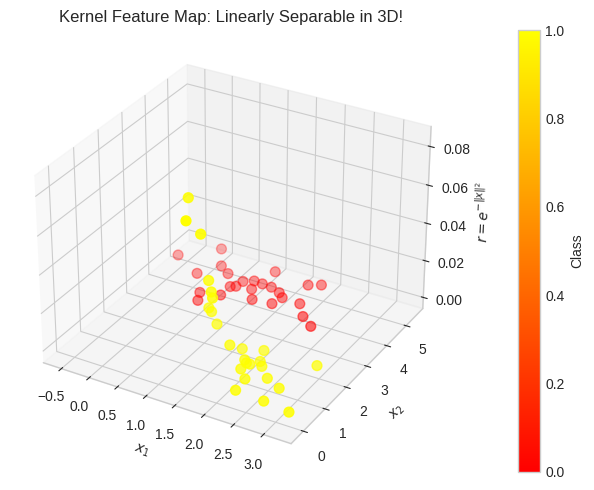

In [33]:
from mpl_toolkits import mplot3d

def plot_3D(X=X, r=r, y=y):
    fig = plt.figure(figsize=(7, 5))
    ax  = fig.add_subplot(111, projection='3d')
    sc  = ax.scatter3D(X[:, 0], X[:, 1], r, c=y, s=50, cmap='autumn')
    ax.set_xlabel('$x_1$')
    ax.set_ylabel('$x_2$')
    ax.set_zlabel('$r = e^{-\\|x\\|^2}$')
    ax.set_title('Kernel Feature Map: Linearly Separable in 3D!')
    plt.colorbar(sc, ax=ax, pad=0.1, label='Class')
    plt.tight_layout()
    plt.show()

plot_3D(X, r, y)

As it can be observed, with this additional dimension, the data becomes trivially linearly separable, by drawing a separating plane at *r*=0.7 (for example, the maximum margin estimator may be slighly higher or lower).

Here we had to choose and carefully tune our projection: if we had not centered our radial basis function in the right location, we would not have seen such clean, linearly separable results.

In general, the need to make such a choice is a problem: we would like to somehow automatically find the best basis functions to use.


One strategy to this end is to compute a basis function centered at *every* point in the dataset, and let the SVM algorithm sift through the results.
This type of basis function transformation is known as a *kernel transformation*, as it is based on a similarity relationship (or kernel) between each pair of points.

A potential problem with this strategy—projecting $N$ points into $N$ dimensions—is that it might become very computationally intensive as $N$ grows large.
However, because of the kernel trick that we saw in class, a fit on kernel-transformed data can be done implicitly—that is, without ever building the full $N$-dimensional representation of the kernel projection!
This kernel trick is built into the SVM, and is one of the reasons the method is so powerful.

In Scikit-Learn, we can apply kernelized SVM simply by changing our linear kernel to an RBF (radial basis function) kernel, using the *kernel* model hyperparameter:

In [34]:
clf = SVC(kernel='rbf', C=1e6) # By default it was kernel='linear'
clf.fit(X, y)

SVC(C=1000000.0)

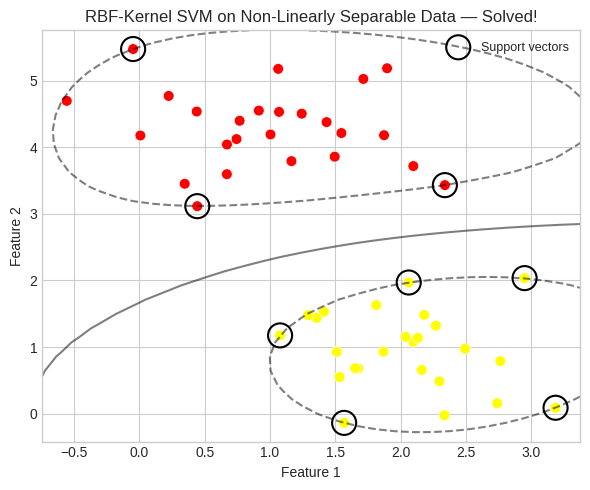

In [35]:
plt.figure(figsize=(6, 5))
plt.scatter(X[:, 0], X[:, 1], c=y, s=60, cmap='autumn',
            edgecolors='white', linewidths=0.5)
plot_svc_decision_function(clf)
plt.scatter(clf.support_vectors_[:, 0], clf.support_vectors_[:, 1],
            s=300, lw=1.5, facecolors='none', edgecolors='k', label='Support vectors')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.title('RBF-Kernel SVM on Non-Linearly Separable Data — Solved!')
plt.legend(fontsize=9)
plt.tight_layout()
plt.show()

Using this kernelized support vector machine, we learned a suitable nonlinear decision boundary.

And finally, the support vector in this case are given by:

In [36]:
clf.support_vectors_

array([[-0.04749204,  5.47425256],
       [ 0.44359863,  3.11530945],
       [ 2.33812285,  3.43116792],
       [ 3.18515794,  0.08900822],
       [ 2.06156753,  1.96918596],
       [ 1.07714851,  1.17533301],
       [ 1.56737975, -0.1381059 ],
       [ 2.94821884,  2.03519717]])

### Soft-Margin SVM: Handling Non-Separable Data

In practice, data is rarely perfectly separable. The **soft-margin SVM** introduces **slack variables** $\xi_i \geq 0$ that allow points to be inside the margin or on the wrong side of the boundary:

$$\min_{\mathbf{w}, b, \boldsymbol{\xi}} \frac{1}{2}\|\mathbf{w}\|^2 + C\sum_{i=1}^m \xi_i$$
$$\text{subject to} \quad y^{(i)}(\mathbf{w}^\top\mathbf{x}^{(i)} + b) \geq 1 - \xi_i, \quad \xi_i \geq 0, \quad \forall i$$

**Interpretation of slack variables:**
- $\xi_i = 0$: point correctly classified and outside (or on) the margin
- $0 < \xi_i \leq 1$: point inside the margin but correctly classified
- $\xi_i > 1$: point is misclassified

**Hinge loss formulation** (equivalent):
$$\mathcal{J}(\mathbf{w}, b) = \underbrace{\frac{1}{2}\|\mathbf{w}\|^2}_{\text{regularisation}} + C\underbrace{\sum_{i=1}^m \max\bigl(0,\, 1 - y^{(i)}(\mathbf{w}^\top\mathbf{x}^{(i)} + b)\bigr)}_{\text{hinge loss}}$$

**The parameter $C$ controls the bias-variance trade-off:**
- Large $C$: penalise misclassifications heavily → small margin, low bias, high variance (overfit)
- Small $C$: allow more violations → wide margin, higher bias, lower variance (underfit)

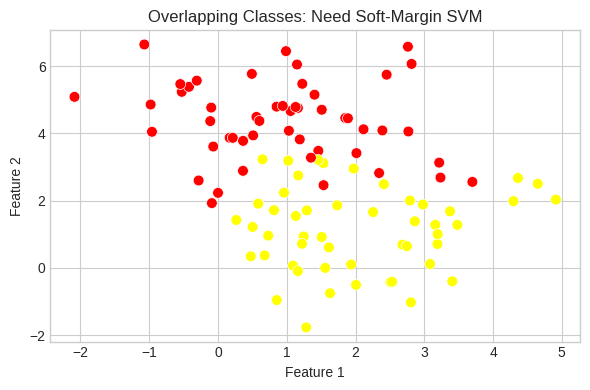

In [37]:
X, y = make_blobs(n_samples=100, centers=2, random_state=0, cluster_std=1.2)

plt.figure(figsize=(6, 4))
plt.scatter(X[:, 0], X[:, 1], c=y, s=60, cmap='autumn', edgecolors='white', linewidths=0.5)
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.title('Overlapping Classes: Need Soft-Margin SVM')
plt.tight_layout()
plt.show()

For this cases, the SVM implementation has a "soften" margin, by allowing some of the points to be inside the margin. This is controlled by the regularization parameter $C$, which controls the *penalty* for allowing points to lie inside the margin.

Therefore, for large values of $C$, fewer points will lie inside, and, for small values of $C$, the margin is softer, allowing margins with more points inside them.

Let's check this with an example.

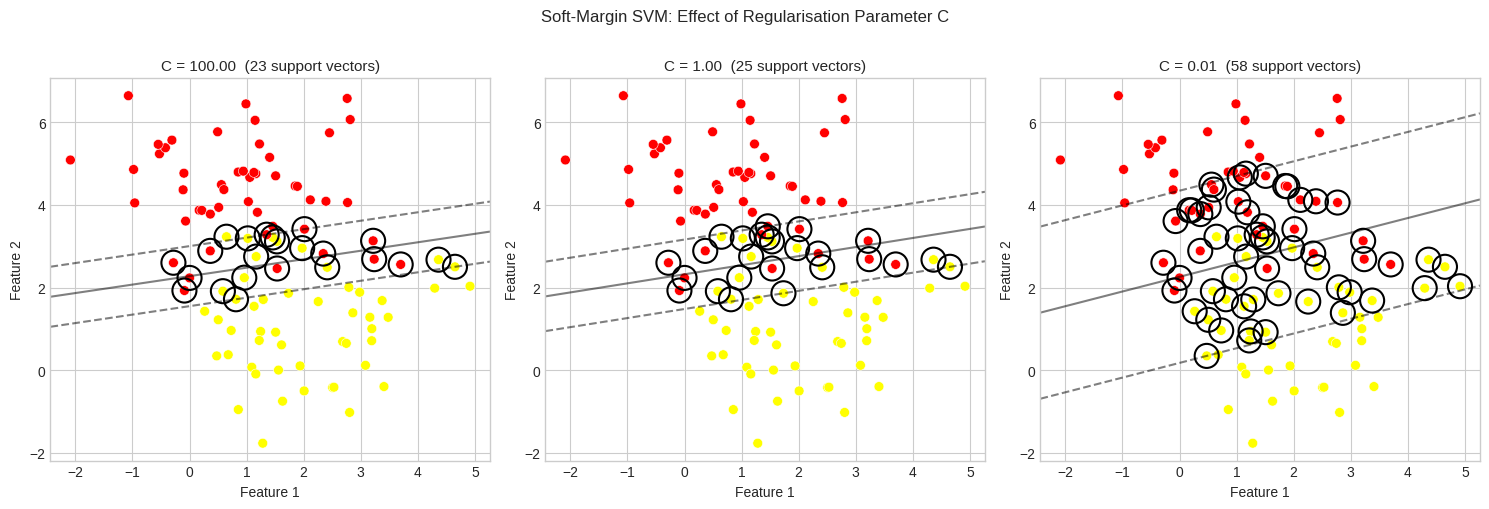

In [38]:
X, y = make_blobs(n_samples=100, centers=2, random_state=0, cluster_std=1.2)

fig, ax = plt.subplots(1, 3, figsize=(15, 5))
fig.subplots_adjust(left=0.0625, right=0.95, wspace=0.1)

for axi, C in zip(ax, [100.0, 1.0, 0.01]):
    model_c = SVC(kernel='linear', C=C).fit(X, y)
    axi.scatter(X[:, 0], X[:, 1], c=y, s=50, cmap='autumn',
                edgecolors='white', linewidths=0.4)
    plot_svc_decision_function(model_c, axi)
    axi.scatter(model_c.support_vectors_[:, 0], model_c.support_vectors_[:, 1],
                s=300, lw=1.5, facecolors='none', edgecolors='k')
    n_sv = len(model_c.support_vectors_)
    axi.set_title(f'C = {C:.2f}  ({n_sv} support vectors)', fontsize=11)
    axi.set_xlabel('Feature 1')
    axi.set_ylabel('Feature 2')

fig.suptitle('Soft-Margin SVM: Effect of Regularisation Parameter C', fontsize=12, y=1.01)
plt.tight_layout()
plt.show()

The optimal $C$ is dataset-dependent and should be selected by **cross-validation**. Too small $C$ → broad margin that may misclassify many points (underfitting). Too large $C$ → narrow margin that tries to classify all training points correctly (overfitting, sensitive to noise).

Let us do a proper grid search with cross-validation:

## Support Vector Machine Summary

### When to Use SVMs

| Property | SVM | Logistic Regression |
|----------|-----|---------------------|
| Decision boundary | Max-margin hyperplane | Separating hyperplane (no margin constraint) |
| Loss function | Hinge loss $\max(0, 1-yf(x))$ | Log-loss $-[y\log\sigma(f) + (1-y)\log(1-\sigma(f))]$ |
| Probabilistic output | Not native (needs Platt scaling) | Yes, calibrated probabilities |
| Influence of data points | Only support vectors | All training points |
| Non-linear boundaries | Via kernel trick | Via feature engineering |
| Large-scale data | Can be slow for $m > 10^5$ | Scales well (SGD) |
| High-dimensional data | Excellent (text classification) | Good |

**Key takeaways:**
1. SVMs find the **maximum-margin** decision boundary — this has strong theoretical justification via VC theory and Structural Risk Minimisation.
2. The **dual formulation** shows that the SVM depends only on inner products → the **kernel trick** enables non-linear boundaries without explicitly computing high-dimensional feature maps.
3. The **soft-margin** parameter $C$ controls the bias-variance trade-off: large $C$ → low bias, high variance; small $C$ → high bias, low variance.
4. **Support vectors** are the only training points that define the model; the boundary is robust to non-support-vector points.

In [39]:
X, y = make_blobs(n_samples=500, centers=2,
          random_state=0, cluster_std=2)

In [40]:
from sklearn.model_selection import train_test_split

X_train, X_valid, y_train, y_valid = train_test_split(X, y, test_size=0.2, random_state=42)


In [41]:
from sklearn.metrics import accuracy_score

print("-" * 45)
print(f"{'C':>8}  |  {'Val Accuracy':>14}")
print("-" * 45)
for C in [100, 1, 0.01]:
    clf_c = SVC(kernel='rbf', C=C)
    clf_c.fit(X_train, y_train)
    acc = accuracy_score(y_valid, clf_c.predict(X_valid))
    print(f"{C:>8}  |  {acc:.4f}  ({acc*100:.2f}%)")
print("-" * 45)

---------------------------------------------
       C  |    Val Accuracy
---------------------------------------------
     100  |  0.8200  (82.00%)
       1  |  0.8500  (85.00%)
    0.01  |  0.7100  (71.00%)
---------------------------------------------


### Proper Hyperparameter Tuning with Cross-Validation

Rather than manually scanning $C$ values, we use **GridSearchCV** to systematically search the hyperparameter space:

Best parameters:  {'svm__C': 0.1, 'svm__gamma': 'scale', 'svm__kernel': 'rbf'}
Best CV accuracy: 0.9067


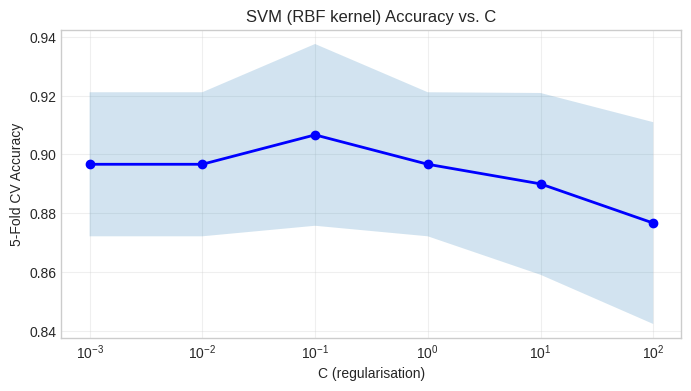

In [42]:
from sklearn.model_selection import GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.datasets import make_blobs
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)
X_cv, y_cv = make_blobs(n_samples=300, centers=2, random_state=0, cluster_std=1.5)

pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('svm', SVC())
])

param_grid = {
    'svm__C':      [0.001, 0.01, 0.1, 1, 10, 100],
    'svm__kernel': ['linear', 'rbf'],
    'svm__gamma':  ['scale', 'auto']
}

grid = GridSearchCV(pipe, param_grid, cv=5, scoring='accuracy', n_jobs=-1, verbose=0)
grid.fit(X_cv, y_cv)

print(f"Best parameters:  {grid.best_params_}")
print(f"Best CV accuracy: {grid.best_score_:.4f}")

# Plot validation accuracy heatmap for RBF kernel
import pandas as pd
results = pd.DataFrame(grid.cv_results_)
rbf_results = results[results['param_svm__kernel']=='rbf'].copy()
rbf_results = rbf_results[rbf_results['param_svm__gamma']=='scale'].copy()
C_vals = [float(p) for p in rbf_results['param_svm__C']]
scores = list(rbf_results['mean_test_score'])
plt.figure(figsize=(8,4))
plt.semilogx(C_vals, scores, 'bo-', lw=2)
plt.fill_between(C_vals,
                 [s - e for s,e in zip(scores, rbf_results['std_test_score'])],
                 [s + e for s,e in zip(scores, rbf_results['std_test_score'])],
                 alpha=0.2)
plt.xlabel('C (regularisation)'); plt.ylabel('5-Fold CV Accuracy')
plt.title('SVM (RBF kernel) Accuracy vs. C'); plt.grid(alpha=0.3)
plt.show()

## Reflection Questions

1. **Maximising margin.** The hard-margin SVM maximises $\frac{2}{\|\mathbf{w}\|}$, subject to all points being correctly classified with margin $\geq 1$. Why is maximising the margin intuitively a good idea? Connect this to the VC dimension and generalisation bounds.

2. **Support vectors.** The KKT complementary slackness condition states $\alpha_i[y^{(i)}(\mathbf{w}^\top\mathbf{x}^{(i)}+b)-1] = 0$. Explain why only points on the margin boundary (support vectors) can have $\alpha_i > 0$. What does this imply if we remove a non-support-vector from the training set?

3. **Kernel trick.** Show that the feature map of the polynomial kernel $K(\mathbf{x},\mathbf{z}) = (\mathbf{x}^\top\mathbf{z} + 1)^2$ for $\mathbf{x} \in \mathbb{R}^2$ is $\phi(\mathbf{x}) = [x_1^2, x_2^2, \sqrt{2}x_1x_2, \sqrt{2}x_1, \sqrt{2}x_2, 1]^\top$. How many dimensions is this? What is the complexity of computing $K$ directly vs. computing $\phi(\mathbf{x})^\top\phi(\mathbf{z})$?

4. **RBF and infinite dimensions.** The RBF kernel corresponds to an infinite-dimensional feature space. Does this mean the SVM with RBF kernel can shatter any finite dataset? What prevents overfitting?

5. **Hinge vs. logistic loss.** Both SVM and logistic regression can be written as regularised loss minimisation. Compare the hinge loss $\max(0, 1-yf)$ and the logistic loss $\log(1+e^{-yf})$. Which is more robust to outliers? Which provides probabilistic predictions?

## Answers to Reflection Questions

**1. Maximising margin and generalisation.**
From VC theory, the generalisation error of a linear classifier is bounded by $\sqrt{\frac{R^2/\gamma^2 + 1}{m}}$ (Vapnik, 1998), where $R$ is the radius of the smallest ball containing the data and $\gamma$ is the margin. Maximising $\gamma$ directly minimises this bound, independent of the input dimension $n$ — explaining why SVMs generalise well in high dimensions.

---

**2. Support vectors and KKT.**
Setting $\nabla_{\mathbf{w}}\mathcal{L} = 0$ gives $\mathbf{w} = \sum_i \alpha_i y^{(i)}\mathbf{x}^{(i)}$.  
KKT complementary slackness: $\alpha_i[y^{(i)}(\mathbf{w}^\top\mathbf{x}^{(i)}+b)-1] = 0$ for each $i$. Therefore $\alpha_i > 0$ only if $y^{(i)}(\mathbf{w}^\top\mathbf{x}^{(i)}+b) = 1$ — the point lies exactly on the margin boundary. Points strictly inside the margin (functional margin > 1) must have $\alpha_i = 0$. Removing a non-support-vector (one with $\alpha_i = 0$) does **not** change $\mathbf{w}$ or $b$ — the model is identical.

---

**3. Kernel trick — polynomial example.**
$K(\mathbf{x},\mathbf{z}) = (\mathbf{x}^\top\mathbf{z}+1)^2 = (x_1 z_1 + x_2 z_2 + 1)^2$  
$= x_1^2 z_1^2 + x_2^2 z_2^2 + 2x_1 x_2 z_1 z_2 + 2x_1 z_1 + 2x_2 z_2 + 1$  
$= \phi(\mathbf{x})^\top\phi(\mathbf{z})$ with $\phi(\mathbf{x}) = [x_1^2, x_2^2, \sqrt{2}x_1 x_2, \sqrt{2}x_1, \sqrt{2}x_2, 1]^\top \in \mathbb{R}^6$.  
Computing $K$ directly: 1 dot product + 1 addition + 1 squaring = $O(n)$.  
Computing $\phi$ then inner product: map to $\mathbb{R}^6$ then dot product = $O(n^2)$ for general degree-2.  
The kernel avoids the explicit mapping — saving computation and memory.

---

**4. RBF and overfitting.**
RBF corresponds to infinite dimensions, but the SVM dual only has $m$ free variables ($\alpha_i$). The VC dimension of the resulting class of functions is controlled by the **margin**, not the ambient dimension. A large margin (small $\|\mathbf{w}\|$, enforced by small $C$) prevents overfitting even in infinite dimensions. So: yes, the RBF SVM can shatter finite datasets with sufficient $C$, but regularisation (small $C$) limits the effective complexity.

---

**5. Hinge vs. logistic loss.**
Both are convex upper bounds on the 0-1 loss. Hinge loss $\max(0,1-yf)$: is **piecewise linear**, exactly zero for $yf \geq 1$ (points outside the margin don't affect the model), produces sparse solutions (only SVs matter). Logistic loss $\log(1+e^{-yf})$: is **smooth**, never exactly zero (all points contribute), provides calibrated probability outputs. Hinge is more robust to outliers because correctly classified points far from the boundary contribute zero gradient; logistic loss applies a small but non-zero gradient to all points.